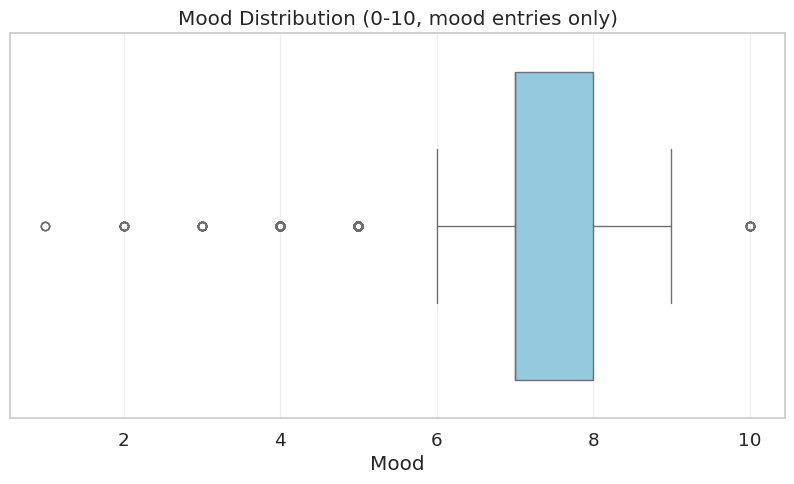

/tmp/ipykernel_28068/2721261787.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weekday', y='value', data=mood_df, order=ordered_weekdays, palette='coolwarm')


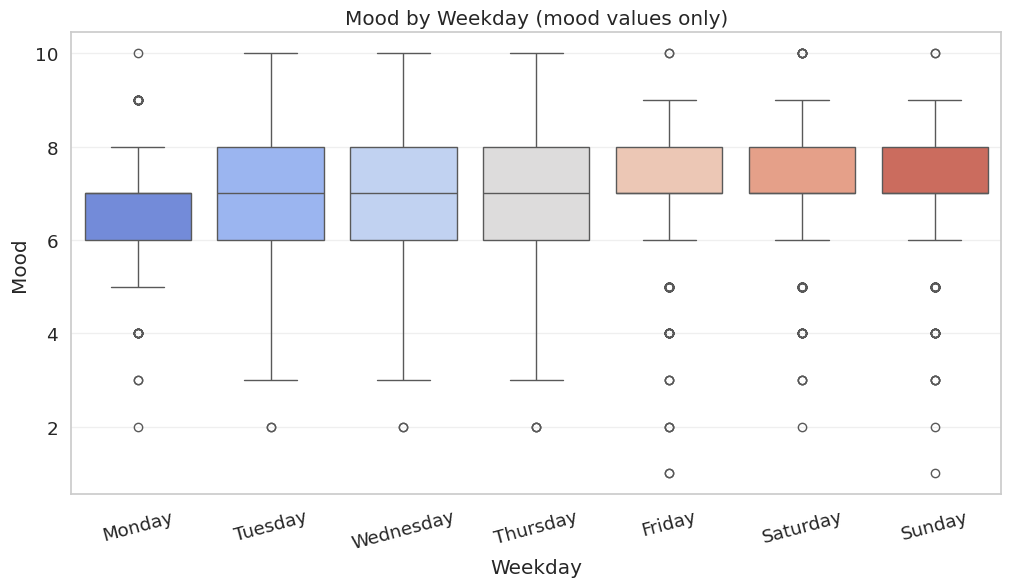

In [3]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# optional for notebook inline display
%matplotlib inline

def load_data(path='dataset_mood_smartphone.csv'):
    df = pd.read_csv(path)
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['time','value']).sort_values('time')
    df['rolling_7'] = df['value'].rolling(7, min_periods=1).mean()
    df['weekday'] = df['time'].dt.day_name()
    return df

def plot_mood_insights(df):
    mood_df = df[df['variable'] == 'mood'].copy()
    if mood_df.empty:
        raise ValueError('No mood records found in dataframe.')

    sns.set(style='whitegrid', palette='muted', font_scale=1.2)

    plt.figure(figsize=(10, 5))
    sns.boxplot(x='value', data=mood_df, color='skyblue')
    plt.title('Mood Distribution (0-10, mood entries only)')
    plt.xlabel('Mood')
    plt.yticks([])
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    ordered_weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='weekday', y='value', data=mood_df, order=ordered_weekdays, palette='coolwarm')
    plt.title('Mood by Weekday (mood values only)')
    plt.xlabel('Weekday')
    plt.ylabel('Mood')
    plt.xticks(rotation=15)
    plt.grid(axis='y', alpha=0.3)
    plt.show()


# run pipeline
full_df = load_data('dataset_mood_smartphone.csv')
plot_mood_insights(full_df)


In [4]:
# Create a wide-form DataFrame where each variable type is a column (value in the cell)
# keeps the original time/id context too
melted = full_df[['id', 'time', 'variable', 'value']].copy()
wide = melted.pivot_table(index=['id','time'], columns='variable', values='value', aggfunc='first')
wide = wide.reset_index()

print('Wide DataFrame shape:', wide.shape)
print(wide.head())

# Example: if there are multiple variable types, each becomes a column
# (unobserved combos become NaN)

# If you want a long format with variable + corresponding value, it's already in `melted`
print('\nLong format (variable + value):')
print(melted.head())

Wide DataFrame shape: (358926, 21)
variable       id                    time  activity  appCat.builtin  \
0         AS14.01 2014-02-17 12:04:42.394       NaN             NaN   
1         AS14.01 2014-02-17 18:28:25.520       NaN             NaN   
2         AS14.01 2014-02-18 09:29:51.257       NaN             NaN   
3         AS14.01 2014-02-19 14:43:30.575       NaN             NaN   
4         AS14.01 2014-02-19 17:29:10.378       NaN             NaN   

variable  appCat.communication  appCat.entertainment  appCat.finance  \
0                          NaN                   NaN             NaN   
1                          NaN                   NaN             NaN   
2                          NaN                   NaN             NaN   
3                          NaN                   NaN             NaN   
4                          NaN                   NaN             NaN   

variable  appCat.game  appCat.office  appCat.other  ...  appCat.travel  \
0                 NaN          